# import libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve, 
    roc_auc_score, 
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay, 
    PrecisionRecallDisplay
)
from sklearn.datasets import make_classification

# Create dataset

Dataset shape: (1000, 3)
Number of class 0 samples: 100
Number of class 1 samples: 900

First 5 samples from class 0:
[[-0.56590642 -0.67744071  0.        ]
 [-1.6999884   0.16223846  0.        ]
 [ 0.43583169  0.13561356  0.        ]
 [-2.48095255 -1.41286869  0.        ]
 [ 0.30223316  0.89312186  0.        ]]

First 5 samples from class 1:
[[2.92641836 3.81637326 1.        ]
 [2.34913029 4.99289075 1.        ]
 [4.09570688 0.76417642 1.        ]
 [2.6989045  3.95710832 1.        ]
 [4.91952825 6.43816475 1.        ]]


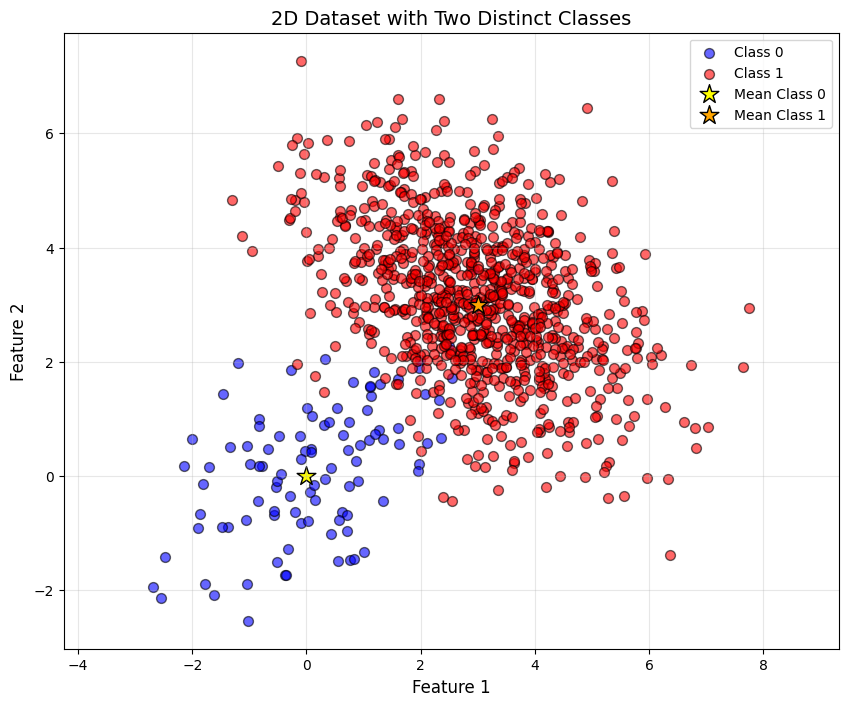


Dataset Statistics:
Class 0 - Mean: [0.13061511 0.15874978]
Class 0 - Std: [1.25518413 1.16844146]
Class 1 - Mean: [2.97754737 3.09977116]
Class 1 - Std: [1.38823676 1.32149633]

Dataset saved to 'two_class_dataset.csv'


In [24]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters for the two classes
class_0_samples = 100
class_1_samples = 900

mean_class0 = np.array([0, 0])
cov_class0 = np.array([[2.0, 1.2], 
                       [1.2, 1.8]])

# Class 1: Now closer to class 0
mean_class1 = np.array([3, 3])  # Changed from [5, 5] to [3, 3]
cov_class1 = np.array([[2.0, -0.9], 
                       [-0.9, 1.8]])

# Generate samples
X0 = np.random.multivariate_normal(mean_class0, cov_class0, class_0_samples)
X1 = np.random.multivariate_normal(mean_class1, cov_class1, class_1_samples)

# Create labels (0 and 1)
y0 = np.zeros(class_0_samples, dtype=int)
y1 = np.ones(class_1_samples, dtype=int)

# Combine into single dataset
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

# Create a single array with features and labels
dataset = np.column_stack((X, y))

print(f"Dataset shape: {dataset.shape}")
print(f"Number of class 0 samples: {np.sum(y == 0)}")
print(f"Number of class 1 samples: {np.sum(y == 1)}")
print("\nFirst 5 samples from class 0:")
print(dataset[y == 0][:5])
print("\nFirst 5 samples from class 1:")
print(dataset[y == 1][:5])

# Visualize the dataset
plt.figure(figsize=(10, 8))

plt.scatter(X0[:, 0], X0[:, 1], alpha=0.6, label='Class 0', 
            color='blue', edgecolors='black', s=50)
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label='Class 1', 
            color='red', edgecolors='black', s=50)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('2D Dataset with Two Distinct Classes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Add means to plot
plt.scatter(mean_class0[0], mean_class0[1], s=200, marker='*', 
            color='yellow', edgecolors='black', label='Mean Class 0')
plt.scatter(mean_class1[0], mean_class1[1], s=200, marker='*', 
            color='orange', edgecolors='black', label='Mean Class 1')

plt.legend()
plt.show()

# Show statistics
print("\nDataset Statistics:")
print("="*50)
print(f"Class 0 - Mean: {np.mean(X0, axis=0)}")
print(f"Class 0 - Std: {np.std(X0, axis=0)}")
print(f"Class 1 - Mean: {np.mean(X1, axis=0)}")
print(f"Class 1 - Std: {np.std(X1, axis=0)}")

# Optional: Save dataset to CSV
np.savetxt('two_class_dataset.csv', dataset, delimiter=',', 
           header='feature1,feature2,label', comments='', fmt='%.6f,%.6f,%d')
print("\nDataset saved to 'two_class_dataset.csv'")

In [25]:
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, stratify=y,random_state=42)

In [26]:
print(f"y_train.shape={y_train.shape}")
print(f"train_class_0_ratio={np.unique_counts(y_train).counts[0]/y_train.shape}")
print(f"train_class_1_ratio={np.unique_counts(y_train).counts[1]/y_train.shape}")
print("*" * 50)
print(f"y_test.shape:{y_test.shape}")
print(f"test_class_0_ratio={np.unique_counts(y_test).counts[0]/y_test.shape}")
print(f"test_class_1_ratio={np.unique_counts(y_test).counts[1]/y_test.shape}")
print(f"y_test.shape:{y_test.shape}")

y_train.shape=(700,)
train_class_0_ratio=[0.1]
train_class_1_ratio=[0.9]
**************************************************
y_test.shape:(300,)
test_class_0_ratio=[0.1]
test_class_1_ratio=[0.9]
y_test.shape:(300,)


# train classification model

In [27]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# print metrics

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"accuracy_score(y_test, y_pred)={accuracy}")
print(f"precision_score(y_test, y_pred)={precision}")
print(f"recall_score(y_test, y_pred)={recall}")
print(f"f1_score(y_test, y_pred)={f1}")

accuracy_score(y_test, y_pred)=0.98
precision_score(y_test, y_pred)=0.9852941176470589
recall_score(y_test, y_pred)=0.9925925925925926
f1_score(y_test, y_pred)=0.988929889298893



Method 5: Comprehensive Confusion Matrix


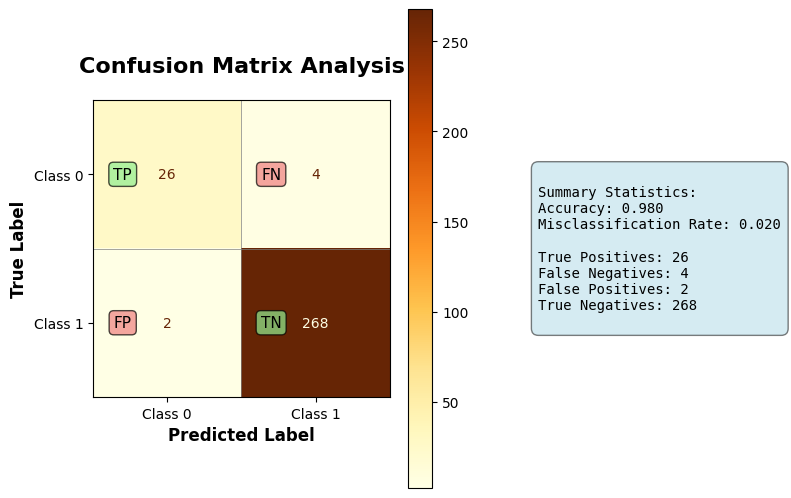

In [29]:
conf_mat = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
# Method 5: Single comprehensive confusion matrix
print("\n" + "="*50)
print("Method 5: Comprehensive Confusion Matrix")
print("="*50)

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 6))

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat,
                             display_labels=['Class 0', 'Class 1'])

# Plot with customizations
disp.plot(ax=ax, cmap='YlOrBr', values_format='d', colorbar=True,
          xticks_rotation=0)

# Add grid
ax.grid(False)
for i in range(3):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
    ax.axvline(i - 0.5, color='gray', linewidth=0.5)

# Add titles and labels
ax.set_title('Confusion Matrix Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')

# Add annotation boxes
ax.text(-0.3, 0, 'TP', fontsize=11, ha='center', va='center', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
ax.text(0.7, 0, 'FN', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
ax.text(-0.3, 1, 'FP', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
ax.text(0.7, 1, 'TN', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Add summary statistics
summary_text = f"""
Summary Statistics:
Accuracy: {accuracy:.3f}
Misclassification Rate: {(1-accuracy):.3f}

True Positives: {conf_mat[0, 0]}
False Negatives: {conf_mat[0, 1]}
False Positives: {conf_mat[1, 0]}
True Negatives: {conf_mat[1, 1]}
"""

ax.text(2.5, 0.5, summary_text, fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.5),
        verticalalignment='center')

plt.tight_layout()
plt.show()

In [41]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]


In [52]:
handy_precisions = np.zeros(9)
handy_recalls = np.zeros(9)

for i in np.arange(1, 10):
    y_pred = np.where(y_pred_proba > i / 10, 1, 0)
    handy_precisions[i-1] = precision_score(y_test, y_pred)
    handy_recalls[i-1] = recall_score(y_test, y_pred)


In [ ]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

In [50]:
type(precisions)

numpy.ndarray

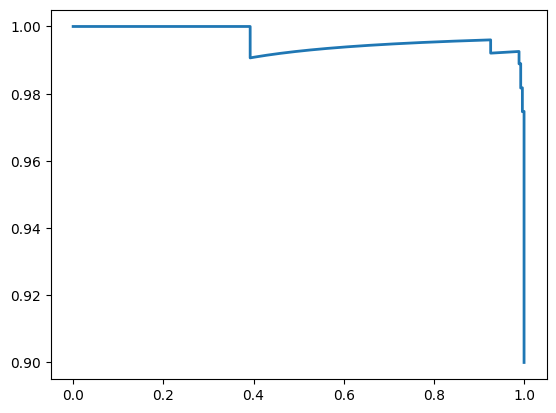

In [44]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

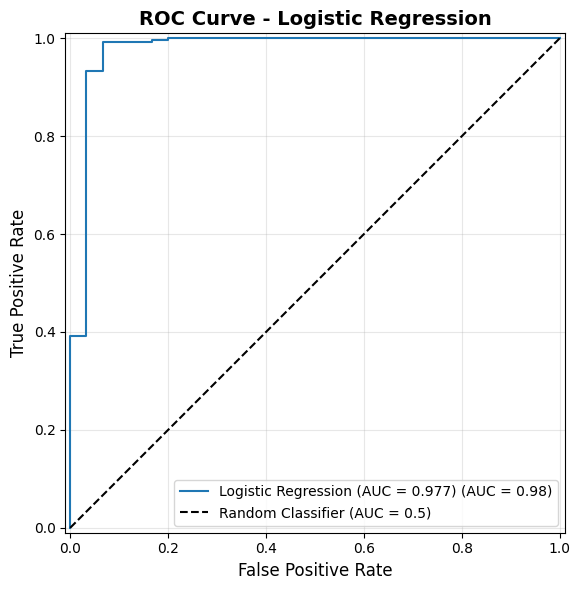

In [30]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

# Plot using RocCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))

# Method 1A: Using RocCurveDisplay.from_estimator
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, 
                               name=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Add diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training set size: (700, 2)
Test set size: (300, 2)
Class distribution: Class 0 = 150, Class 1 = 150

METHOD 1: Basic ROC Curve


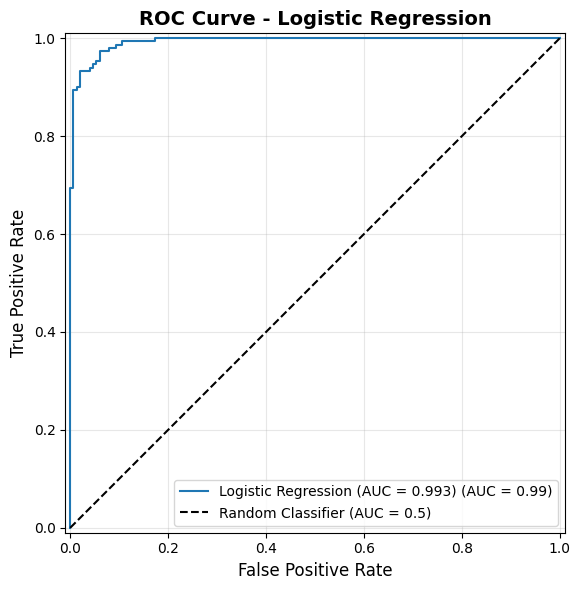

Logistic Regression AUC: 0.9928

METHOD 2: Multiple Classifiers Comparison


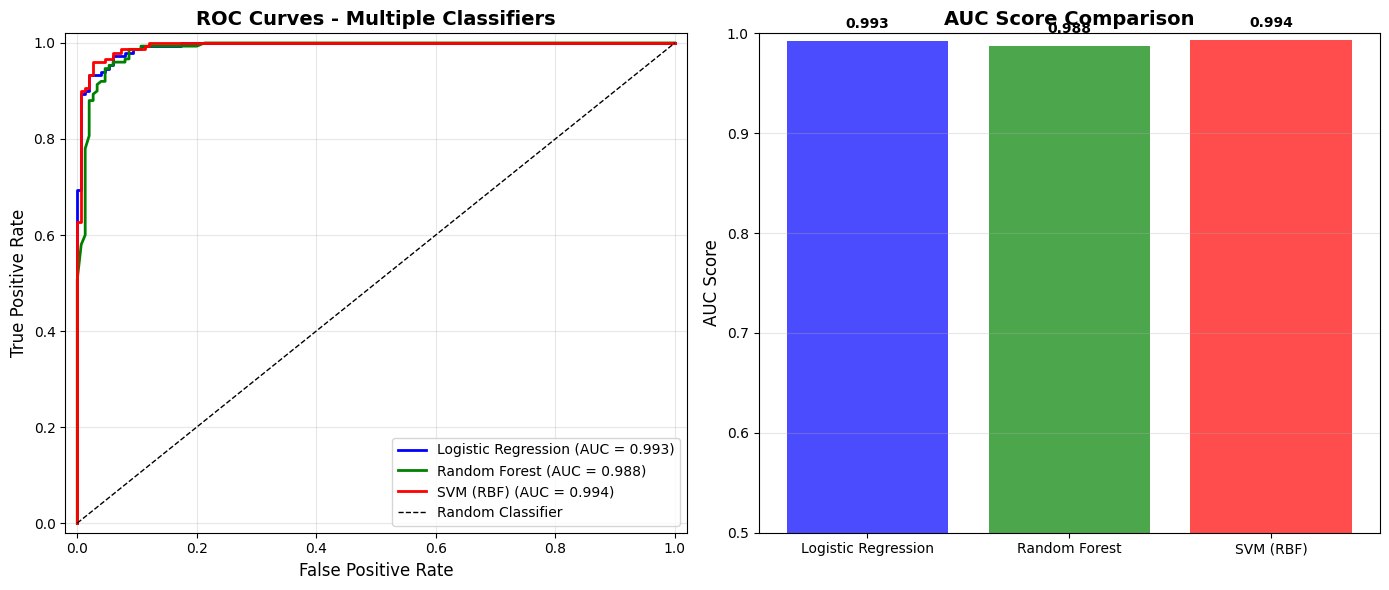


METHOD 3: Detailed ROC Analysis with Thresholds


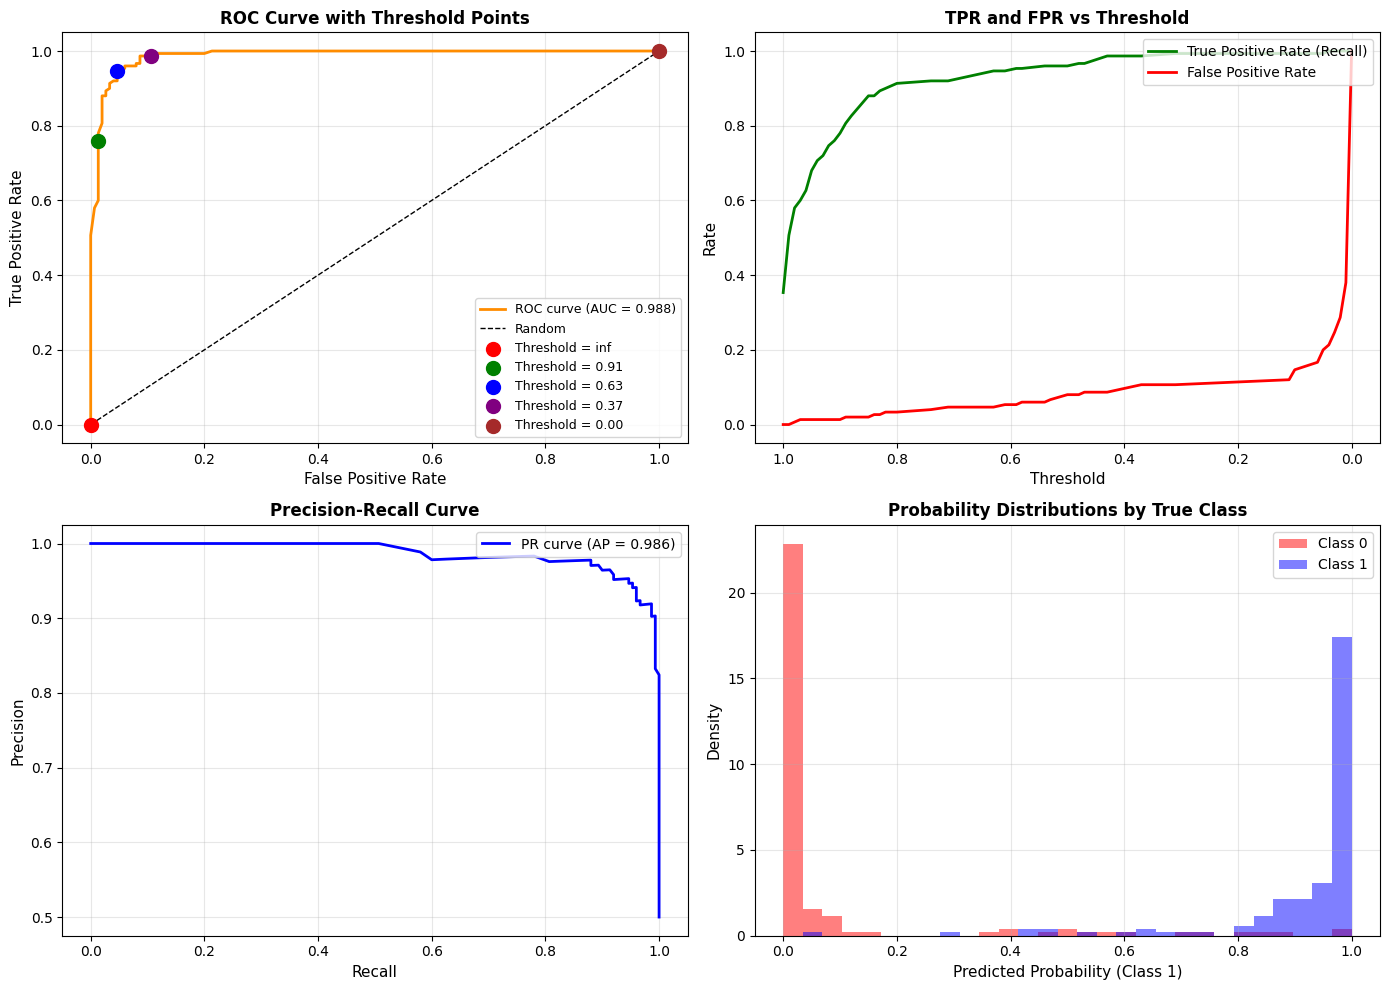


METHOD 4: Optimal Threshold Selection


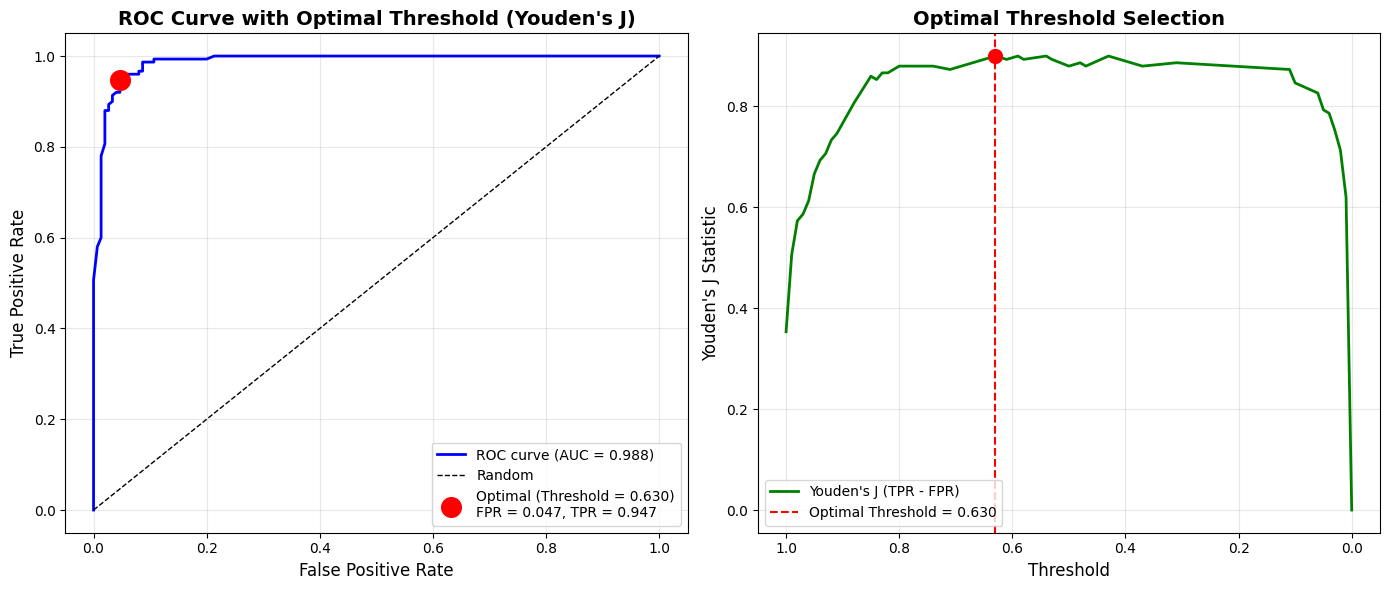


Optimal Threshold Analysis:
----------------------------------------
Optimal Threshold: 0.6300
Youden's J Statistic: 0.9000

Performance at Optimal Threshold:
Accuracy: 0.9500
Precision: 0.9530
Recall: 0.9467
F1-Score: 0.9498

METHOD 5: ROC for Imbalanced Data
Imbalanced Dataset:
  Class 0: 560 train, 240 test
  Class 1: 140 train, 60 test
  Class ratio: 80.00% vs 20.00%


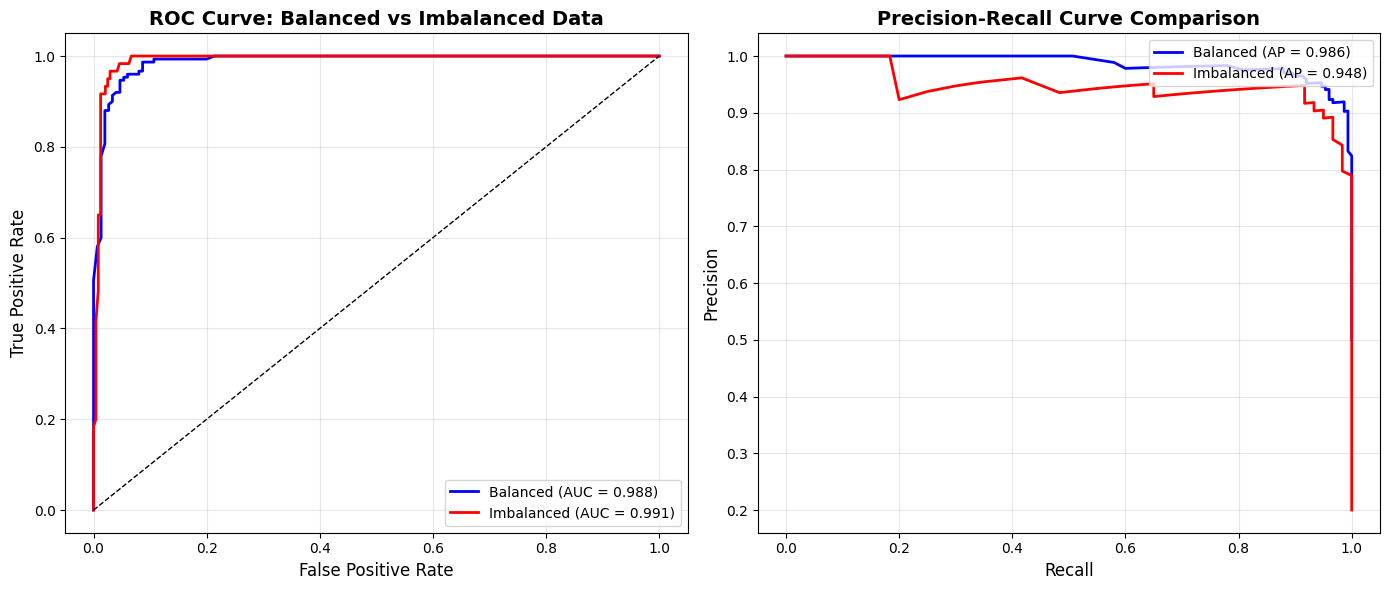


Imbalanced Data Analysis:
----------------------------------------
Balanced Data AUC: 0.9876
Imbalanced Data AUC: 0.9909
Balanced Data Average Precision: 0.9857
Imbalanced Data Average Precision: 0.9480


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Create dataset with some overlap
n_samples_per_class = 500

# Class 0
mean_class0 = np.array([0, 0])
cov_class0 = np.array([[2.0, 1.2], 
                       [1.2, 1.8]])

# Class 1 - closer to class 0
mean_class1 = np.array([3, 3])
cov_class1 = np.array([[2.0, -0.9], 
                       [-0.9, 1.8]])

# Generate samples
X0 = np.random.multivariate_normal(mean_class0, cov_class0, n_samples_per_class)
X1 = np.random.multivariate_normal(mean_class1, cov_class1, n_samples_per_class)

# Create labels
y = np.hstack((np.zeros(n_samples_per_class), np.ones(n_samples_per_class)))
X = np.vstack((X0, X1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution: Class 0 = {np.sum(y_test == 0)}, Class 1 = {np.sum(y_test == 1)}")

# ============================================================================
# METHOD 1: Basic ROC Curve using sklearn's RocCurveDisplay
# ============================================================================

print("\n" + "="*50)
print("METHOD 1: Basic ROC Curve")
print("="*50)

# Train a logistic regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

# Plot using RocCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))

# Method 1A: Using RocCurveDisplay.from_estimator
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, 
                               name=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Add diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {roc_auc_lr:.4f}")

# ============================================================================
# METHOD 2: Multiple Classifiers Comparison
# ============================================================================

print("\n" + "="*50)
print("METHOD 2: Multiple Classifiers Comparison")
print("="*50)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale the data for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# Plot ROC curves for all classifiers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: ROC curves
ax1 = axes[0]
colors = ['blue', 'green', 'red']

for (name, clf), color in zip(classifiers.items(), colors):
    if name == 'SVM (RBF)':
        clf.fit(X_train_scaled, y_train)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Plot ROC curve
    ax1.plot(fpr, tpr, color=color, lw=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Store for later use
    if name == 'Random Forest':
        fpr_rf, tpr_rf, roc_auc_rf = fpr, tpr, roc_auc

# Add diagonal line and formatting
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - Multiple Classifiers', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# Subplot 2: AUC comparison bar chart
ax2 = axes[1]

# Calculate AUC for each classifier
auc_scores = []
for name, clf in classifiers.items():
    if name == 'SVM (RBF)':
        clf.fit(X_train_scaled, y_train)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
    
    auc_scores.append(roc_auc_score(y_test, y_pred_proba))

# Create bar chart
bars = ax2.bar(classifiers.keys(), auc_scores, color=colors, alpha=0.7)
ax2.set_ylim([0.5, 1.0])
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('AUC Score Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# METHOD 3: Detailed ROC Analysis with Thresholds
# ============================================================================

print("\n" + "="*50)
print("METHOD 3: Detailed ROC Analysis with Thresholds")
print("="*50)

# Use Random Forest for detailed analysis
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Get ROC curve data
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ROC Curve with threshold points
ax1 = axes[0, 0]
ax1.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Mark some specific thresholds
threshold_indices = [0, len(thresholds_rf)//4, len(thresholds_rf)//2, 
                    3*len(thresholds_rf)//4, -1]
threshold_colors = ['red', 'green', 'blue', 'purple', 'brown']

for idx, color in zip(threshold_indices, threshold_colors):
    ax1.scatter(fpr_rf[idx], tpr_rf[idx], color=color, s=100, zorder=5,
                label=f'Threshold = {thresholds_rf[idx]:.2f}')

ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve with Threshold Points', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Threshold vs TPR/FPR
ax2 = axes[0, 1]
ax2.plot(thresholds_rf, tpr_rf, 'g-', lw=2, label='True Positive Rate (Recall)')
ax2.plot(thresholds_rf, fpr_rf, 'r-', lw=2, label='False Positive Rate')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Rate', fontsize=11)
ax2.set_title('TPR and FPR vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()  # Threshold decreases from left to right

# 3. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf)
avg_precision = average_precision_score(y_test, y_pred_proba_rf)

ax3 = axes[1, 0]
ax3.plot(recall, precision, 'b-', lw=2, 
         label=f'PR curve (AP = {avg_precision:.3f})')
ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# 4. Distribution of predicted probabilities
ax4 = axes[1, 1]
bins = np.linspace(0, 1, 30)
ax4.hist(y_pred_proba_rf[y_test == 0], bins=bins, alpha=0.5, 
         color='red', label='Class 0', density=True)
ax4.hist(y_pred_proba_rf[y_test == 1], bins=bins, alpha=0.5, 
         color='blue', label='Class 1', density=True)
ax4.set_xlabel('Predicted Probability (Class 1)', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_title('Probability Distributions by True Class', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# METHOD 4: Interactive ROC with Youden's J Statistic
# ============================================================================

print("\n" + "="*50)
print("METHOD 4: Optimal Threshold Selection")
print("="*50)

# Calculate Youden's J statistic (TPR - FPR) for each threshold
youden_j = tpr_rf - fpr_rf
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds_rf[optimal_idx]

# Calculate metrics at optimal threshold
y_pred_optimal = (y_pred_proba_rf >= optimal_threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

optimal_accuracy = accuracy_score(y_test, y_pred_optimal)
optimal_precision = precision_score(y_test, y_pred_optimal)
optimal_recall = recall_score(y_test, y_pred_optimal)
optimal_f1 = f1_score(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC with optimal threshold
ax1 = axes[0]
ax1.plot(fpr_rf, tpr_rf, 'b-', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Mark optimal point
ax1.scatter(fpr_rf[optimal_idx], tpr_rf[optimal_idx], 
            color='red', s=200, zorder=5,
            label=f'Optimal (Threshold = {optimal_threshold:.3f})\n'
                  f'FPR = {fpr_rf[optimal_idx]:.3f}, TPR = {tpr_rf[optimal_idx]:.3f}')

ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve with Optimal Threshold (Youden\'s J)', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: Youden's J statistic
ax2 = axes[1]
ax2.plot(thresholds_rf, youden_j, 'g-', lw=2, label="Youden's J (TPR - FPR)")
ax2.axvline(x=optimal_threshold, color='r', linestyle='--', 
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.scatter(optimal_threshold, youden_j[optimal_idx], 
            color='red', s=100, zorder=5)

ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel("Youden's J Statistic", fontsize=12)
ax2.set_title('Optimal Threshold Selection', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

print("\nOptimal Threshold Analysis:")
print("-" * 40)
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Youden's J Statistic: {youden_j[optimal_idx]:.4f}")
print(f"\nPerformance at Optimal Threshold:")
print(f"Accuracy: {optimal_accuracy:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")
print(f"F1-Score: {optimal_f1:.4f}")

# ============================================================================
# METHOD 5: ROC for Different Class Ratios (Imbalanced Data)
# ============================================================================

print("\n" + "="*50)
print("METHOD 5: ROC for Imbalanced Data")
print("="*50)

# Create imbalanced dataset
np.random.seed(42)
n_class0 = 800  # Majority class
n_class1 = 200  # Minority class

X0_imb = np.random.multivariate_normal(mean_class0, cov_class0, n_class0)
X1_imb = np.random.multivariate_normal(mean_class1, cov_class1, n_class1)

X_imb = np.vstack((X0_imb, X1_imb))
y_imb = np.hstack((np.zeros(n_class0), np.ones(n_class1)))

# Split imbalanced data
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

print(f"Imbalanced Dataset:")
print(f"  Class 0: {np.sum(y_train_imb == 0)} train, {np.sum(y_test_imb == 0)} test")
print(f"  Class 1: {np.sum(y_train_imb == 1)} train, {np.sum(y_test_imb == 1)} test")
print(f"  Class ratio: {np.sum(y_imb == 0)/len(y_imb):.2%} vs {np.sum(y_imb == 1)/len(y_imb):.2%}")

# Train model on imbalanced data
rf_imb = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_imb.fit(X_train_imb, y_train_imb)
y_pred_proba_imb = rf_imb.predict_proba(X_test_imb)[:, 1]

# Calculate ROC for imbalanced data
fpr_imb, tpr_imb, _ = roc_curve(y_test_imb, y_pred_proba_imb)
roc_auc_imb = roc_auc_score(y_test_imb, y_pred_proba_imb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC comparison balanced vs imbalanced
ax1 = axes[0]
ax1.plot(fpr_rf, tpr_rf, 'b-', lw=2, 
         label=f'Balanced (AUC = {roc_auc_rf:.3f})')
ax1.plot(fpr_imb, tpr_imb, 'r-', lw=2, 
         label=f'Imbalanced (AUC = {roc_auc_imb:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve: Balanced vs Imbalanced Data', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: Precision-Recall comparison
precision_imb, recall_imb, _ = precision_recall_curve(y_test_imb, y_pred_proba_imb)
avg_precision_imb = average_precision_score(y_test_imb, y_pred_proba_imb)

ax2 = axes[1]
ax2.plot(recall, precision, 'b-', lw=2, 
         label=f'Balanced (AP = {avg_precision:.3f})')
ax2.plot(recall_imb, precision_imb, 'r-', lw=2, 
         label=f'Imbalanced (AP = {avg_precision_imb:.3f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nImbalanced Data Analysis:")
print("-" * 40)
print(f"Balanced Data AUC: {roc_auc_rf:.4f}")
print(f"Imbalanced Data AUC: {roc_auc_imb:.4f}")
print(f"Balanced Data Average Precision: {avg_precision:.4f}")
print(f"Imbalanced Data Average Precision: {avg_precision_imb:.4f}")